# 实验3 复杂网络的度相关性

以下代码从课件截图中提取并按片段整理为 Notebook。

- 第 1 段：无权网络的节点的余平均度 `<knn>i`、度同配系数、度皮尔逊相关系数
- 第 2 段：加权网络的节点的余平均度 `<knn>i`、度同配系数、度皮尔逊相关系数
- 第 3 段：定义函数求余平均度 `<knn>(k)` 并绘图

注：第 2 段课件中使用的 `actor_edges.csv` 当前目录下未提供，因此这里保留课件原始写法。

节点的度为: [(1, 1), (2, 4), (3, 1), (4, 4), (5, 3), (6, 1), (7, 2)]
节点的余平均度<knn>i为: {1: 4.0, 2: 2.25, 3: 4.0, 4: 2.5, 5: 3.3333333333333335, 6: 4.0, 7: 3.5}
网络的度同配系数为: -0.5454545454545454
网络的度皮尔逊相关系数为: -0.5454545454545453


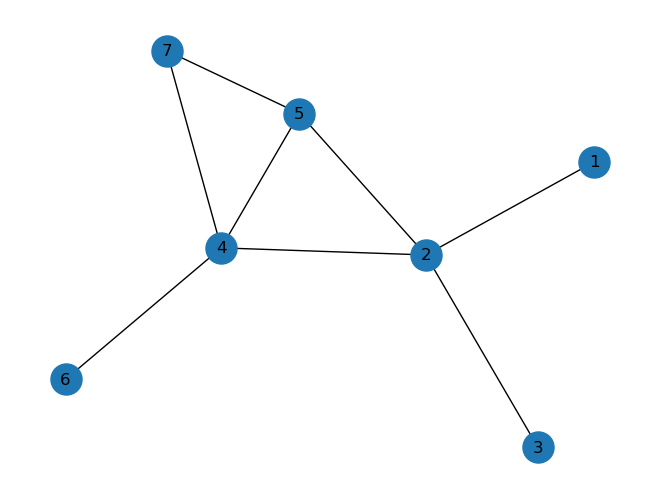

In [7]:
import networkx as nx

G = nx.Graph()
G.add_nodes_from([1, 2, 3, 4, 5, 6, 7])
G.add_edges_from([(1, 2), (2, 3), (2, 4), (2, 5), (4, 5), (4, 6), (4, 7), (5, 7)])

nx.draw(G, node_size=500, with_labels=True)
print("节点的度为:", nx.degree(G))
print("节点的余平均度<knn>i为:", nx.average_neighbor_degree(G))
print("网络的度同配系数为:", nx.degree_assortativity_coefficient(G))
print("网络的度皮尔逊相关系数为:", nx.degree_pearson_correlation_coefficient(G))


节点的度为: [(0, 18), (8, 43), (10, 53), (25, 54), (1, 62), (5, 62), (11, 35), (17, 49), (23, 27), (27, 61), (29, 29), (31, 32), (35, 32), (38, 19), (47, 37), (50, 38), (53, 35), (57, 34), (2, 45), (3, 10), (28, 81), (33, 22), (41, 17), (56, 35), (40, 29), (4, 60), (6, 18), (15, 18), (22, 54), (34, 26), (36, 14), (39, 21), (9, 39), (24, 18), (14, 16), (7, 7), (43, 19), (12, 32), (18, 44), (19, 34), (26, 13), (13, 20), (42, 2), (21, 15), (32, 9), (37, 2)]
节点的余平均度<knn>i为: {0: 19.0, 8: 17.093023255813954, 10: 14.433962264150944, 25: 14.444444444444445, 1: 15.403225806451612, 5: 13.516129032258064, 11: 14.142857142857142, 17: 15.591836734693878, 23: 16.925925925925927, 27: 14.721311475409836, 29: 16.93103448275862, 31: 16.71875, 35: 16.0625, 38: 19.526315789473685, 47: 13.35135135135135, 50: 14.447368421052632, 53: 12.714285714285714, 57: 18.323529411764707, 2: 14.733333333333333, 3: 12.6, 28: 13.469135802469136, 33: 17.227272727272727, 41: 15.529411764705882, 56: 14.657142857142857, 40: 15.620

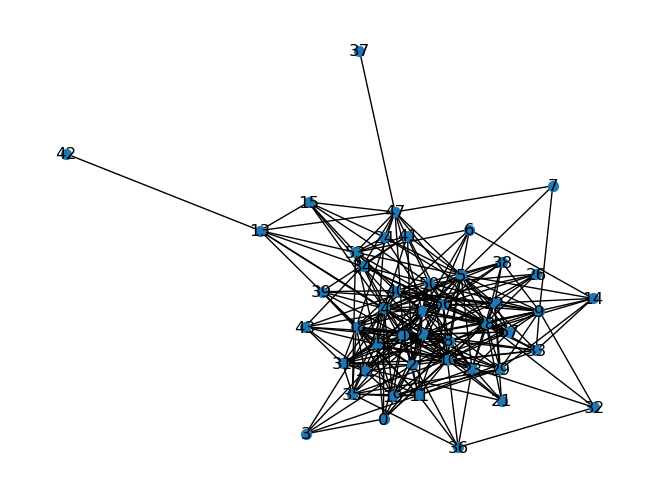

In [8]:
import numpy as np
import networkx as nx
import pandas as pd
import matplotlib.pyplot as plt
import csv

df = pd.read_csv("actor_edges.csv")
G = nx.from_pandas_edgelist(df, 'from', 'to', 'weight', create_using=nx.Graph())

print("节点的度为:", nx.degree(G, weight="weight"))
print("节点的余平均度<knn>i为:", nx.average_neighbor_degree(G, weight="weight"))
print("网络的度同配系数为:", nx.degree_assortativity_coefficient(G, weight="weight"))
print("网络的度皮尔逊相关系数为:", nx.degree_pearson_correlation_coefficient(G, weight="weight"))

nx.draw(G, node_size=50, with_labels=True)
plt.show()


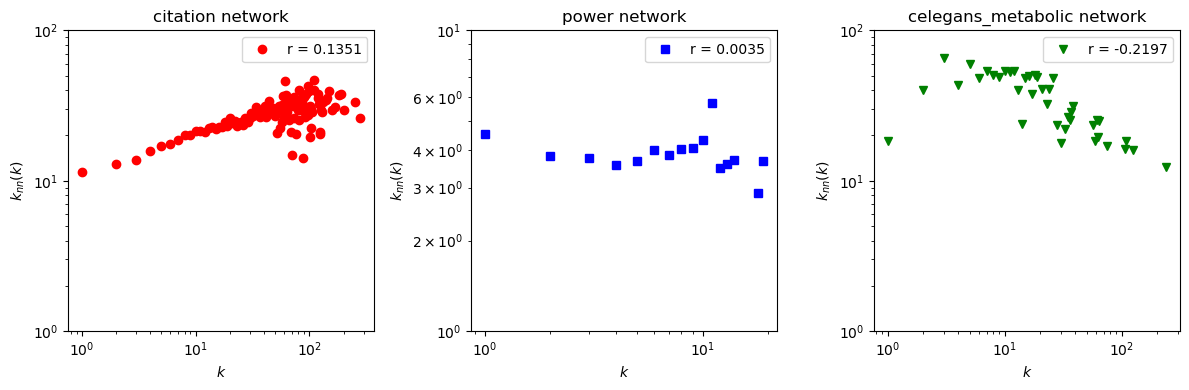

In [3]:
# 度-度相关性
# 导入库
import networkx as nx
import matplotlib.pyplot as plt
import pandas as pd

# 加载三个真实数据集
# 1. 科学合作网络
df1 = pd.read_csv("citation.csv")
G1 = nx.from_pandas_edgelist(df1, 'source', 'target', create_using=nx.Graph())

# 2. 电网
df2 = pd.read_csv("power.csv")
G2 = nx.from_pandas_edgelist(df2, 'source', 'target', create_using=nx.Graph())

# 3. 代谢网络
df3 = pd.read_csv("celegans_metabolic.csv")
G3 = nx.from_pandas_edgelist(df3, 'source', 'target', create_using=nx.Graph())

# 网络中度为 k 的节点为 v1, v2, ..., vi，则度为 k 的节点的余平均度为每个节点 vi 的余平均度的和的平均
# 定义求余平均度 <knn>(k) 的函数
def average_nearest_neighbor_degree(G):
    k = set([G.degree(i) for i in G.nodes()])  # 获取所有可能的度值并去重
    sorted_k = sorted(k)

    k_nn_k = []
    for ki in sorted_k:
        c = 0
        k_nn_i = 0
        for i in G.nodes():
            if G.degree(i) == ki:
                k_nn_i += sum([G.degree(j) for j in list(nx.all_neighbors(G, i))]) / ki
                c += 1
        k_nn_k.append(k_nn_i / c)

    return sorted_k, k_nn_k


r1 = nx.degree_assortativity_coefficient(G1)
r2 = nx.degree_assortativity_coefficient(G2)
r3 = nx.degree_assortativity_coefficient(G3)

x1, y1 = average_nearest_neighbor_degree(G1)
x2, y2 = average_nearest_neighbor_degree(G2)
x3, y3 = average_nearest_neighbor_degree(G3)

plt.figure(figsize=(12, 4))

plt.subplot(131)
plt.plot(x1, y1, 'ro', label='r = ' + '%.4f' % r1)
plt.legend(loc=0)
plt.xlabel("$k$")
plt.ylabel("$k_{nn}(k)$")
plt.xscale("log")
plt.yscale("log")
plt.title('citation network')
plt.ylim([1, 100])

plt.subplot(132)
plt.plot(x2, y2, 'bs', label='r = ' + '%.4f' % r2)
plt.legend(loc=0)
plt.xlabel("$k$")
plt.ylabel("$k_{nn}(k)$")
plt.xscale("log")
plt.yscale("log")
plt.title('power network')
plt.ylim([1, 10])

plt.subplot(133)
plt.plot(x3, y3, 'gv', label='r = ' + '%.4f' % r3)
plt.legend(loc=0)
plt.xlabel("$k$")
plt.ylabel("$k_{nn}(k)$")
plt.xscale("log")
plt.yscale("log")
plt.title('celegans_metabolic network')
plt.ylim([1, 100])

plt.tight_layout()
